In [4]:
from ultralytics import YOLO

# Load a COCO-pretrained YOLO26s model
model = YOLO("yolo26s.pt")

In [ ]:
# import os
# os.chdir(r"D:\Y3\Sem2\Deep Learning\student-behavior-detection-yolo26")

In [ ]:
import torch

if torch.cuda.is_available():
    DEVICE = 0  # Ultralytics uses GPU index (0 = first CUDA GPU)
    print(f"GPU detected: {torch.cuda.get_device_name(0)}")
else:
    DEVICE = "cpu"
    print("No GPU detected. Using CPU.")

print("DEVICE =", DEVICE)

GPU detected: NVIDIA GeForce RTX 4050 Laptop GPU
DEVICE = 0


In [5]:
model.train(
    project=r"D:\Y3\Sem2\Deep Learning\student-behavior-detection-yolo26\runs\detect",
    # Data
    data="StudentWatch_no_hr.yaml",
    name="train",
    imgsz=[720, 1280],

    # Augmentation
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=5.0,
    translate=0.10,
    scale=0.30,
    shear=2.0,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.10,

    # Hyperparameters
    epochs=5,
    patience=50,
    batch=2,

    device=DEVICE,
)

Ultralytics 8.4.37  Python-3.10.11 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=StudentWatch_no_hr.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=[720, 1280], int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_ma

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000204B0C5DC90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
    

In [15]:
from ultralytics import YOLO
model = YOLO("runs/detect/train3/weights/best.pt")
metrics = model.val(project=r"D:\Y3\Sem2\Deep Learning\student-behavior-detection-yolo26\runs\detect",
                    data="StudentWatch_no_hr.yaml", split="val", device=0, plots=True)
print("mAP50:", metrics.box.map50, "mAP50-95:", metrics.box.map)

Ultralytics 8.4.37  Python-3.10.11 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
YOLO26s summary (fused): 122 layers, 9,467,115 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1635.585.6 MB/s, size: 303.7 KB)
val: Scanning D:\Y3\Sem2\Deep Learning\student-behavior-detection-yolo26\sb_no_hr\valid\labels.cache... 67 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 67/67  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.6it/s 3.2s1.0s
                   all         67       1935      0.904      0.881      0.919      0.749
       bowing_the_head         38         94      0.848      0.809      0.848       0.65
learning_over_the_table         58         99      0.959      0.954      0.984      0.755
               reading         67        782      0.887      0.829      0.893      0.741
           using_phone         67        631      0.935      0.915     

In [3]:
from ultralytics import YOLO
model = YOLO("runs/detect/train3/weights/best.pt")
metrics = model.val(project=r"D:\Y3\Sem2\Deep Learning\student-behavior-detection-yolo26\runs\detect",
                    data="StudentWatch_no_hr.yaml", split="test", device=0)
print("mAP50:", metrics.box.map50, "mAP50-95:", metrics.box.map)

Ultralytics 8.4.37  Python-3.10.11 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
YOLO26s summary (fused): 122 layers, 9,467,115 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access  (ping: 0.30.1 ms, read: 25.45.3 MB/s, size: 303.3 KB)
val: Scanning D:\Y3\Sem2\Deep Learning\student-behavior-detection-yolo26\sb_no_hr\test\labels.cache... 33 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 33/33  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.0s/it 6.1s2.7s2s
                   all         33       1048      0.928       0.88      0.921      0.737
       bowing_the_head         26         67      0.912      0.821      0.874      0.632
learning_over_the_table         32         54      0.961      0.944       0.99      0.774
               reading         33        406      0.906      0.835      0.888      0.718
           using_phone         33        391      0.952      0.915      0

## Plot Training Graphs from Existing Run
This rebuilds the main training curves from `runs/detect/train3/results.csv` after moving the run folder.

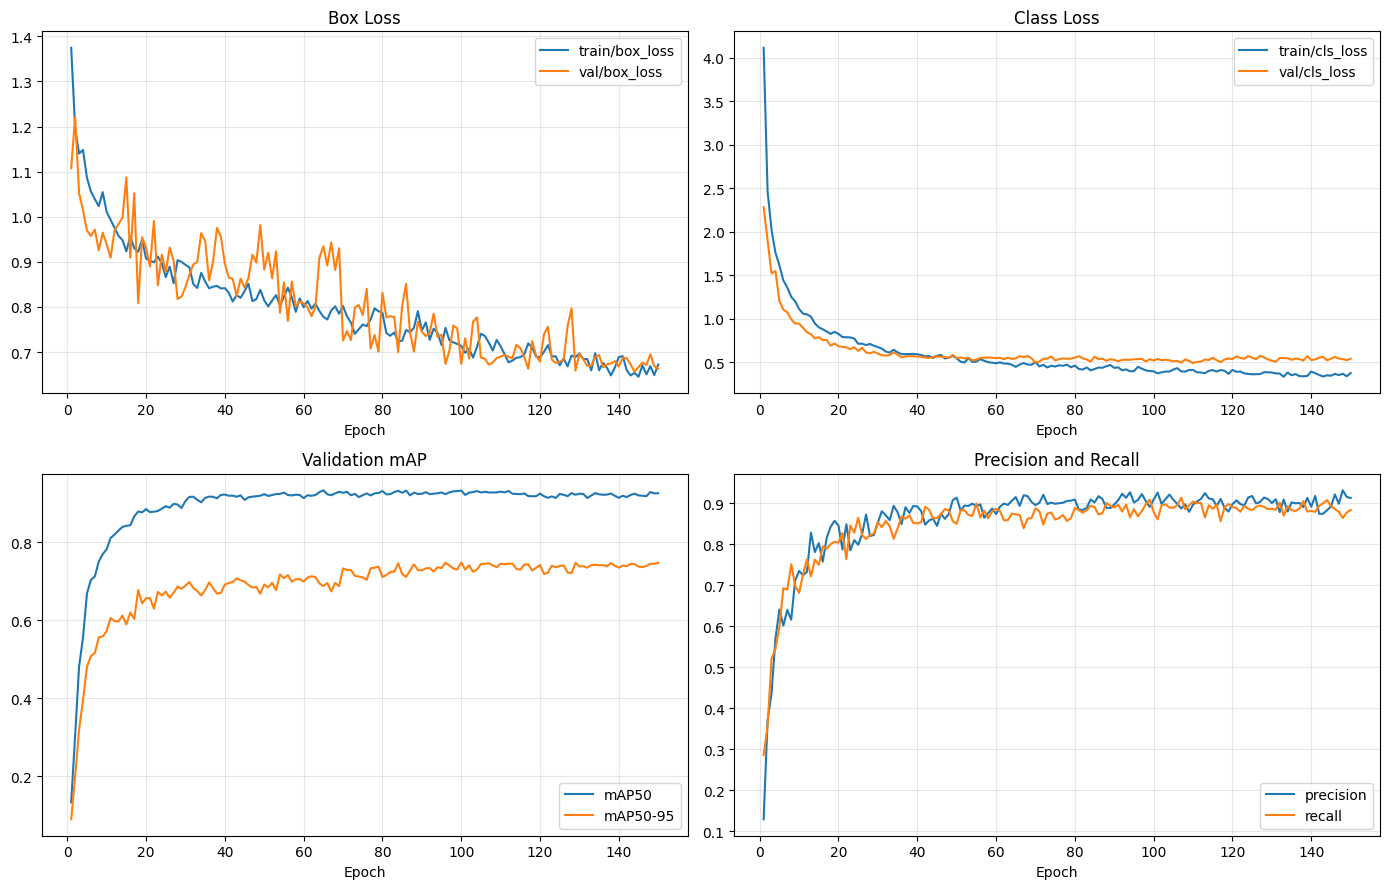

In [7]:
from pathlib import Path
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

csv_path = Path("runs/detect/train2/results.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"Could not find {csv_path}. Check your run folder path.")

df = pd.read_csv(csv_path)
df.columns = [c.strip() for c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

axes[0].plot(df["epoch"], df["train/box_loss"], label="train/box_loss")
axes[0].plot(df["epoch"], df["val/box_loss"], label="val/box_loss")
axes[0].set_title("Box Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df["epoch"], df["train/cls_loss"], label="train/cls_loss")
axes[1].plot(df["epoch"], df["val/cls_loss"], label="val/cls_loss")
axes[1].set_title("Class Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
axes[2].plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
axes[2].set_title("Validation mAP")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

axes[3].plot(df["epoch"], df["metrics/precision(B)"], label="precision")
axes[3].plot(df["epoch"], df["metrics/recall(B)"], label="recall")
axes[3].set_title("Precision and Recall")
axes[3].set_xlabel("Epoch")
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Inference on Test Image (GT vs Prediction)
This cell picks a test image, draws ground-truth boxes on the left, and model predictions on the right.

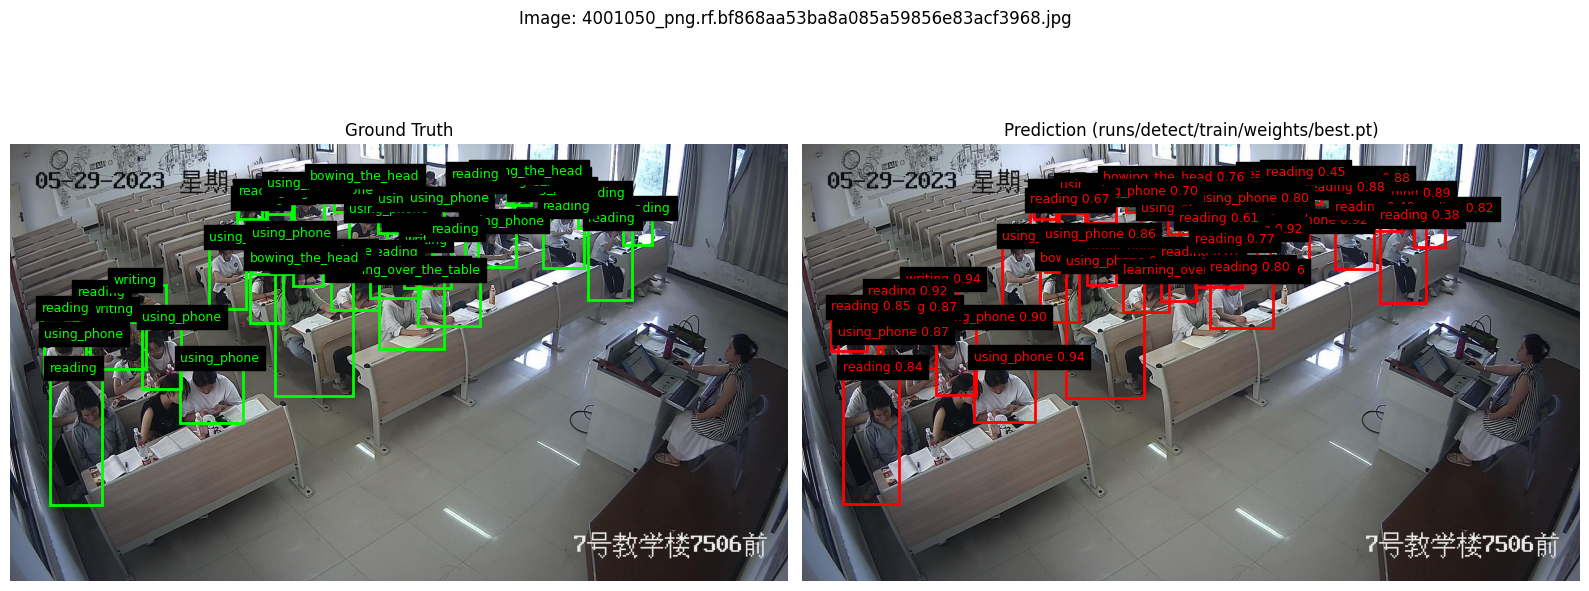

In [18]:
from pathlib import Path
import random
import cv2
import yaml
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ultralytics import YOLO

best_checkpoint = "runs/detect/train/weights/best.pt"

# Load dataset config and class names.
with open("StudentWatch_no_hr.yaml", "r", encoding="utf-8") as f:
    data_cfg = yaml.safe_load(f)
class_names = data_cfg["names"]

test_img_dir = Path("sb_no_hr") / data_cfg["test"]
test_lbl_dir = test_img_dir.parent / "labels"
if not test_img_dir.exists() or not test_lbl_dir.exists():
    raise FileNotFoundError("Test image/label folders not found. Check StudentWatch_no_hr.yaml paths.")

image_files = sorted([
    p for p in test_img_dir.iterdir()
    if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
])
if not image_files:
    raise FileNotFoundError(f"No test images found in {test_img_dir}")

random.seed(42)
img_path = random.choice(image_files)
label_path = test_lbl_dir / f"{img_path.stem}.txt"

# Read image (OpenCV BGR -> RGB).
img_bgr = cv2.imread(str(img_path))
if img_bgr is None:
    raise RuntimeError(f"Failed to read image: {img_path}")
img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

# Left panel: Ground truth boxes from YOLO label file (normalized xywh).
img_gt = img.copy()
gt_boxes = []
if label_path.exists():
    with open(label_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls_id, xc, yc, bw, bh = parts
            cls_id = int(float(cls_id))
            xc, yc, bw, bh = map(float, (xc, yc, bw, bh))

            x1 = (xc - bw / 2.0) * w
            y1 = (yc - bh / 2.0) * h
            x2 = (xc + bw / 2.0) * w
            y2 = (yc + bh / 2.0) * h
            gt_boxes.append((cls_id, x1, y1, x2, y2))

# Right panel: Predictions from model.
infer_model = YOLO(best_checkpoint)
pred = infer_model.predict(source=str(img_path), conf=0.25, device=0, verbose=False)[0]
pred_boxes = pred.boxes

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(img_gt)
axes[0].set_title("Ground Truth")
axes[1].imshow(img)
axes[1].set_title(f"Prediction ({best_checkpoint})")

# Draw GT boxes.
for cls_id, x1, y1, x2, y2 in gt_boxes:
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor="lime", facecolor="none")
    axes[0].add_patch(rect)
    label = class_names.get(cls_id, str(cls_id)) if isinstance(class_names, dict) else class_names[cls_id]
    axes[0].text(x1, max(0, y1 - 4), f"{label}", color="lime", fontsize=9, backgroundcolor="black")

# Draw predicted boxes.
if pred_boxes is not None and len(pred_boxes) > 0:
    xyxy = pred_boxes.xyxy.cpu().numpy()
    confs = pred_boxes.conf.cpu().numpy()
    clss = pred_boxes.cls.cpu().numpy().astype(int)
    for (x1, y1, x2, y2), conf, cls_id in zip(xyxy, confs, clss):
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor="red", facecolor="none")
        axes[1].add_patch(rect)
        label = class_names.get(cls_id, str(cls_id)) if isinstance(class_names, dict) else class_names[cls_id]
        axes[1].text(x1, max(0, y1 - 4), f"{label} {conf:.2f}", color="red", fontsize=9, backgroundcolor="black")

for ax in axes:
    ax.axis("off")

plt.suptitle(f"Image: {img_path.name}")
plt.tight_layout()
plt.show()


image 1/1 d:\Y3\Sem2\Deep Learning\student-behavior-detection-yolo26\sb_no_hr\test\images\4003106_png.rf.a8f3da7690a5a88ad57fa4228c95c4c2.jpg: 384x640 1 learning_over_the_table, 15 readings, 7 using_phones, 7 writings, 15.3ms
Speed: 1.3ms preprocess, 15.3ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)


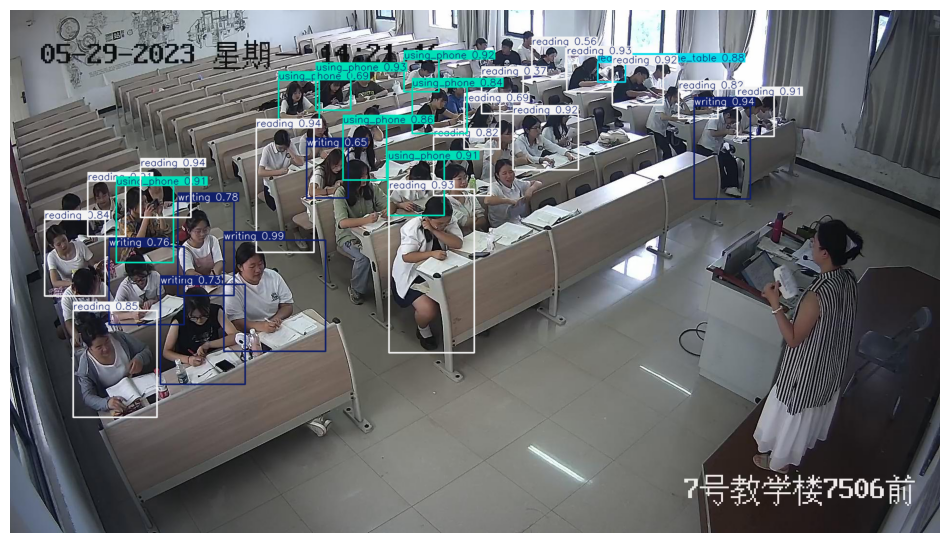

In [16]:
import cv2
from ultralytics import YOLO

%matplotlib inline
import matplotlib.pyplot as plt

image_path = "sb_no_hr/test/images/4003106_png.rf.a8f3da7690a5a88ad57fa4228c95c4c2.jpg"

best_checkpoint = "runs/detect/train/weights/best.pt"
model = YOLO(best_checkpoint)

results = model.predict(source=image_path)
annotated_bgr = results[0].plot(font_size=12, line_width=2, conf=0.3)

annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

# 4. Plot using Matplotlib
plt.figure(figsize=(12, 8))
plt.imshow(annotated_rgb)
plt.axis("off")
plt.show()

In [20]:
import time
import cv2
from ultralytics import YOLO

best_checkpoint = "runs/detect/train/weights/best.pt"
model = YOLO(best_checkpoint)

# Try default webcam index 0. If this fails, try 1 or 2.
cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)
if not cap.isOpened():
    raise RuntimeError("Could not open webcam. Try changing VideoCapture index to 1 or 2.")

print("Webcam started. Press 'q' to quit.")
prev_t = time.time()

while True:
    ok, frame = cap.read()
    if not ok:
        print("Failed to read frame from webcam.")
        break

    # Run YOLO inference on this frame.
    results = model.predict(source=frame, conf=0.5, iou=0.5, device=0, verbose=False)
    annotated = results[0].plot()

    # Compute and draw FPS.
    cur_t = time.time()
    fps = 1.0 / max(cur_t - prev_t, 1e-6)
    prev_t = cur_t
    cv2.putText(
        annotated,
        f"FPS: {fps:.1f}",
        (10, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.0,
        (0, 255, 0),
        2,
        cv2.LINE_AA,
    )

    cv2.imshow("Student Behavior Detection - Live", annotated)
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

Webcam started. Press 'q' to quit.
